In [45]:
import numpy as np
import random
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import copy
import itertools
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [21]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Часть 1

In [22]:
def gen_fig1(n):
    X = np.random.uniform(-1, 1, size=(n,2))
    y = ((X[:,0] * X[:,1]) > 0).astype(int)
    return X.astype(np.float32), y.astype(np.int64)
def gen_fig2(n):
    X = np.random.uniform(-1, 1, size=(n,2))
    r = np.sqrt((X**2).sum(axis=1))
    y = np.zeros(n)
    y[(r < 0.2) | (r > 0.6)] = 1
    return X.astype(np.float32), y.astype(np.int64)
def gen_fig3(n):
    centers = np.array([[-0.6,0.6],[0.6,0.6],[-0.6,-0.6]])
    per_blob = np.random.randint(int(n*0.1), int(n*0.2), size=(3,))
    X_list = []
    y_list = []
    for i, c in enumerate(centers):
        pts = c + 0.1 * np.random.randn(per_blob[i],2)
        X_list.append(pts);
        y_list.append(np.ones(len(pts)))
    bg = np.random.uniform(-1, 1, size=(n - per_blob.sum(), 2))
    X_list.append(bg)
    y_list.append(np.zeros(len(bg), dtype=int))
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    idx = np.arange(len(y))
    np.random.shuffle(idx)
    return X[idx].astype(np.float32), y[idx].astype(np.int64)

In [23]:
N_train = 1000; N_val = 200
train_sets = []
train_sets.append(gen_fig1(N_train))
train_sets.append(gen_fig2(N_train))
train_sets.append(gen_fig3(N_train))
val_sets = []
val_sets.append(gen_fig1(N_val))
val_sets.append(gen_fig2(N_val))
val_sets.append(gen_fig3(N_val))

In [24]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.l = nn.Linear(2,1)

    def forward(self,x):
        return self.l(x)

class MLP1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2,100),
                                 nn.ReLU(),
                                 nn.Linear(100,1))

    def forward(self,x):
        return self.net(x)

class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2,60),
                                 nn.ReLU(),
                                 nn.Linear(60,100),
                                 nn.ReLU(),
                                 nn.Linear(100,1))

    def forward(self,x):
        return self.net(x)

In [25]:
def train (name, model, X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=1e-3):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    ds = TensorDataset(torch.from_numpy(X_train).to(device), torch.from_numpy(y_train).float().unsqueeze(1).to(device))
    train_loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    ds = TensorDataset(torch.from_numpy(X_val).to(device), torch.from_numpy(y_val).float().unsqueeze(1).to(device))
    test_loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    history = {"train_loss":[], "val_loss":[], "val_acc":[]}

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for data, target in train_loader:
            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)

        epoch_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds = []
        with torch.no_grad():
            for data, target in test_loader:
                data = data.to(device)
                target = target.to(device)

                output = model(data)
                loss = criterion(output, target)
                val_loss += loss.item() * data.size(0)

                probs = torch.sigmoid(output).cpu().numpy().ravel()
                preds = (probs > 0.5).astype(int)
                all_preds.append(torch.tensor(preds))

            all_preds = torch.cat(all_preds).numpy()
            val_loss /= len(test_loader)
            acc = (all_preds==y_val).mean()

            history["train_loss"].append(epoch_train_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(acc)

        mins = X_val.min(axis=0)-0.25; maxs = X_val.max(axis=0)+0.25
        xs = np.linspace(mins[0], maxs[0], 200)
        ys = np.linspace(mins[1], maxs[1], 200)
        xx,yy = np.meshgrid(xs,ys)
        grid = np.column_stack([xx.ravel(),yy.ravel()]).astype(np.float32)
        grid = torch.from_numpy(grid).to(device)
        with torch.no_grad():
            g_logits = model(grid)
            g_probs = torch.sigmoid(g_logits).cpu().numpy().reshape(xx.shape)
        plt.figure(figsize=(5,5))
        plt.contour(xx,yy,g_probs,levels=[0.5])
        plt.scatter(X_val[:,0],X_val[:,1],c=y_val)
        plt.title(f"{name} | Epoch {epoch}")
        plt.show()
        print(f"train_loss = {history['train_loss'][epoch-1]:.4f}, val_loss = {history['val_loss'][epoch-1]:.4f}, val_acc = {history['val_acc'][epoch-1]:.4f}")

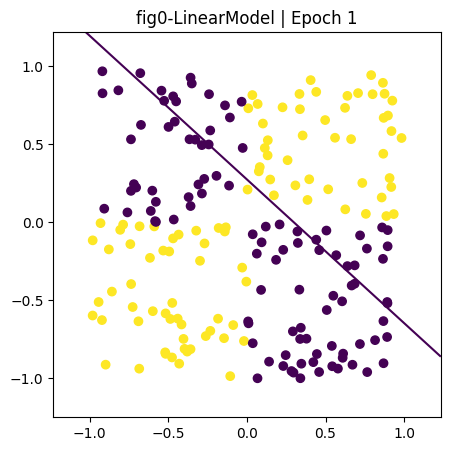

train_loss = 45.2556, val_loss = 35.7032, val_acc = 0.6050


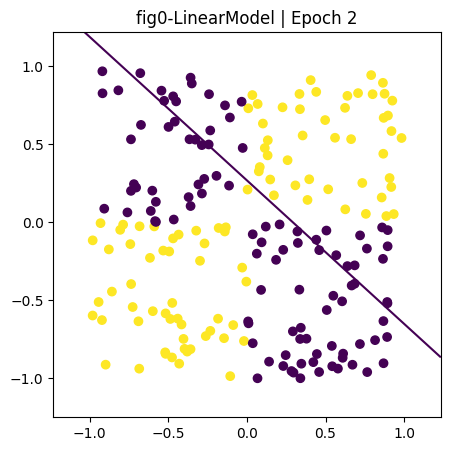

train_loss = 45.1570, val_loss = 35.6462, val_acc = 0.6050


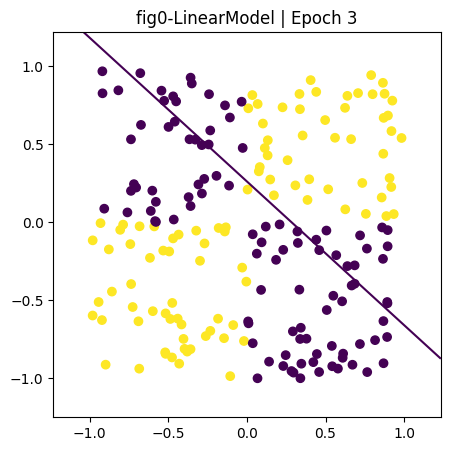

train_loss = 45.0743, val_loss = 35.5897, val_acc = 0.6050


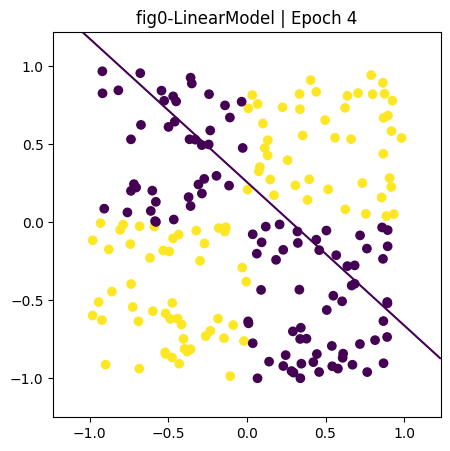

train_loss = 44.9903, val_loss = 35.5352, val_acc = 0.6050


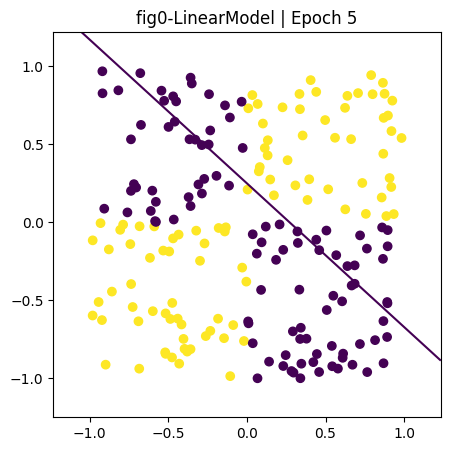

train_loss = 44.9125, val_loss = 35.4832, val_acc = 0.6050


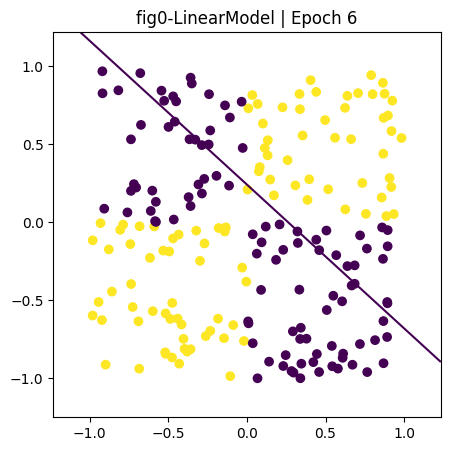

train_loss = 44.8321, val_loss = 35.4389, val_acc = 0.6000


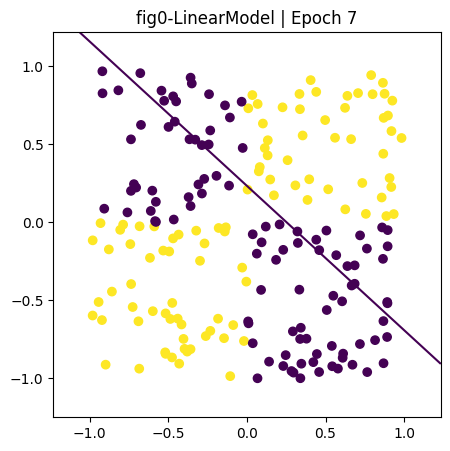

train_loss = 44.7679, val_loss = 35.3938, val_acc = 0.5900


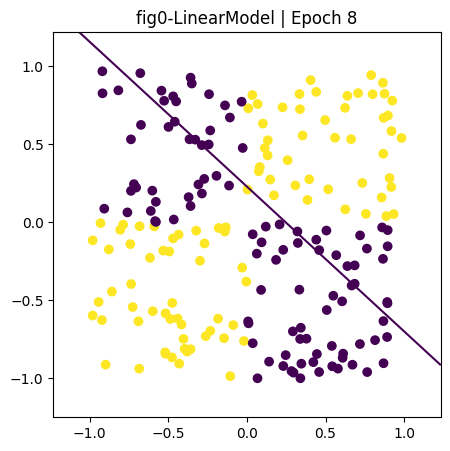

train_loss = 44.6967, val_loss = 35.3536, val_acc = 0.5900


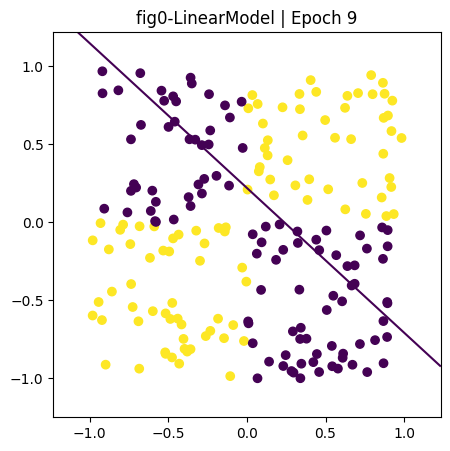

train_loss = 44.6355, val_loss = 35.3114, val_acc = 0.5800


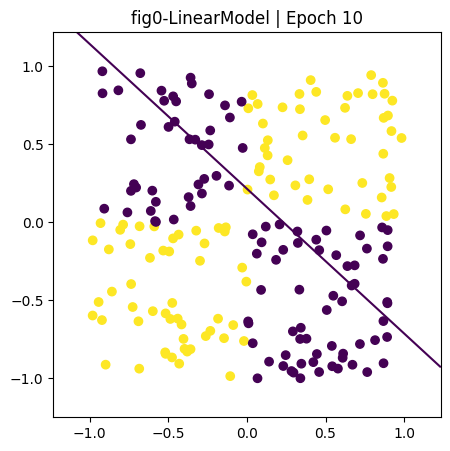

train_loss = 44.5708, val_loss = 35.2728, val_acc = 0.5750


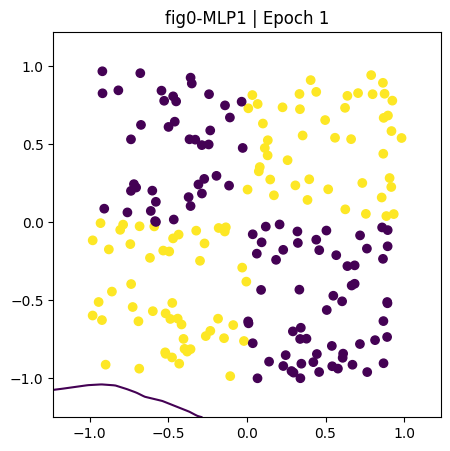

train_loss = 43.3488, val_loss = 34.3331, val_acc = 0.5100


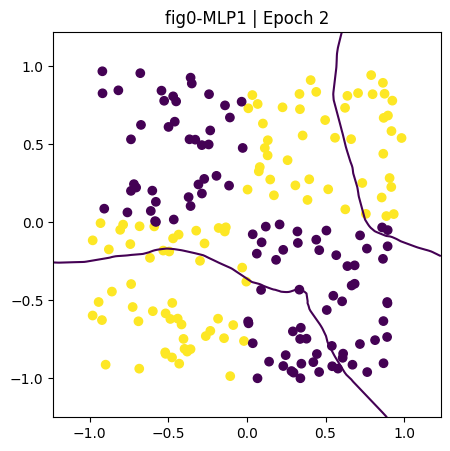

train_loss = 41.6855, val_loss = 33.3150, val_acc = 0.6700


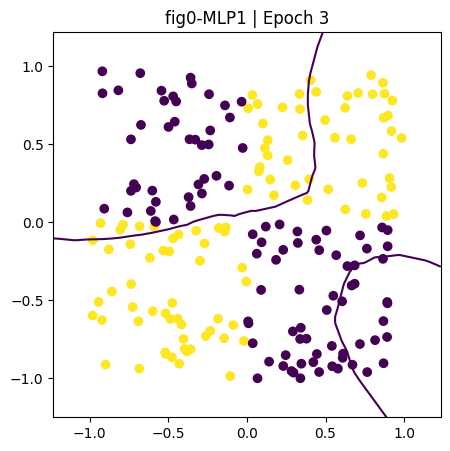

train_loss = 40.2562, val_loss = 32.4353, val_acc = 0.6450


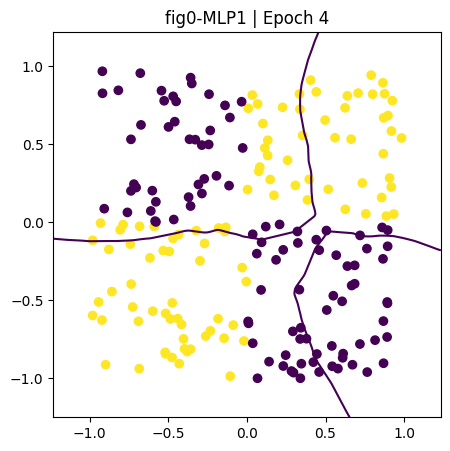

train_loss = 38.7783, val_loss = 31.3870, val_acc = 0.7100


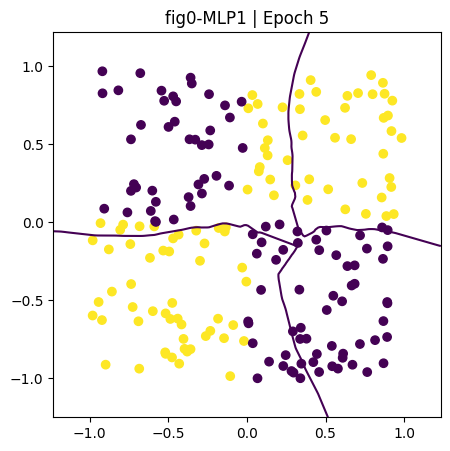

train_loss = 37.1755, val_loss = 30.1710, val_acc = 0.8100


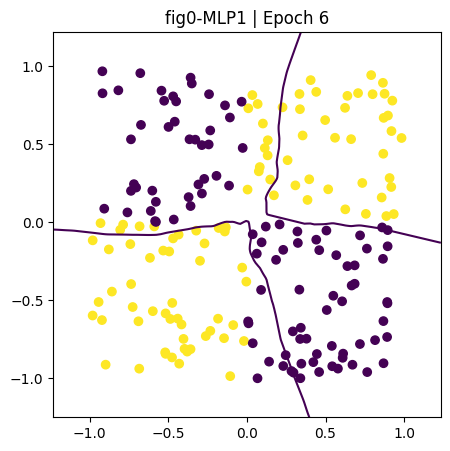

train_loss = 35.4198, val_loss = 28.8357, val_acc = 0.8650


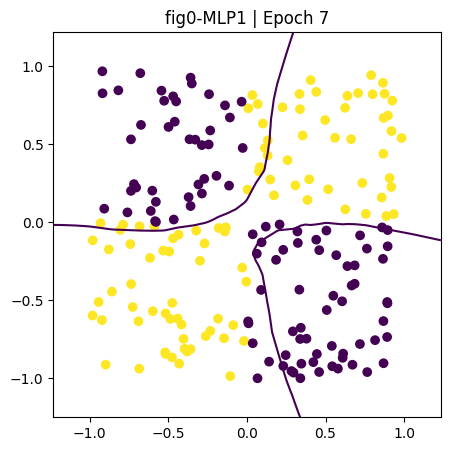

train_loss = 33.5380, val_loss = 27.3541, val_acc = 0.8850


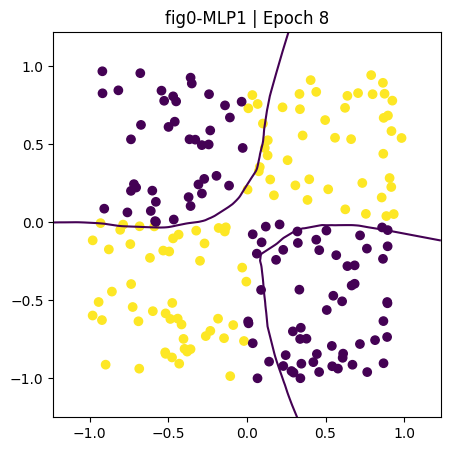

train_loss = 31.6008, val_loss = 25.8610, val_acc = 0.8950


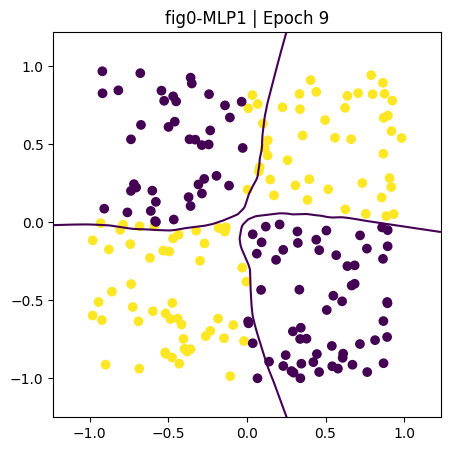

train_loss = 29.6157, val_loss = 24.2716, val_acc = 0.9350


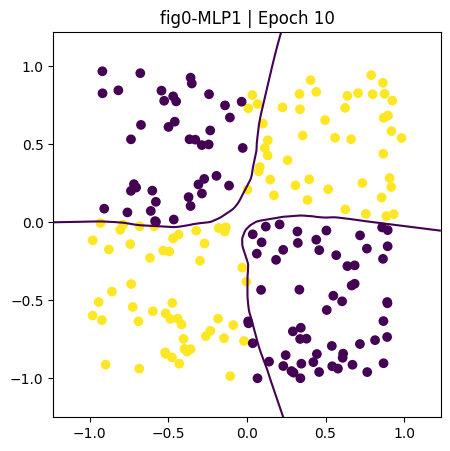

train_loss = 27.6640, val_loss = 22.7256, val_acc = 0.9650


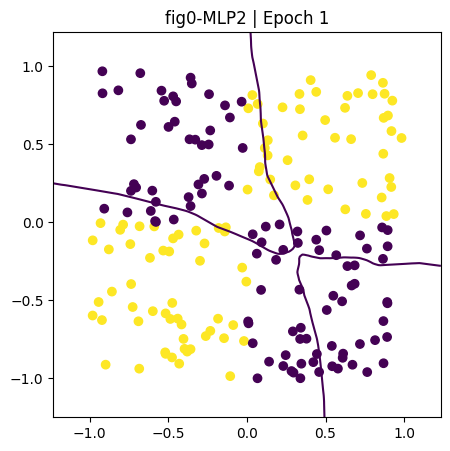

train_loss = 42.5738, val_loss = 32.9302, val_acc = 0.7600


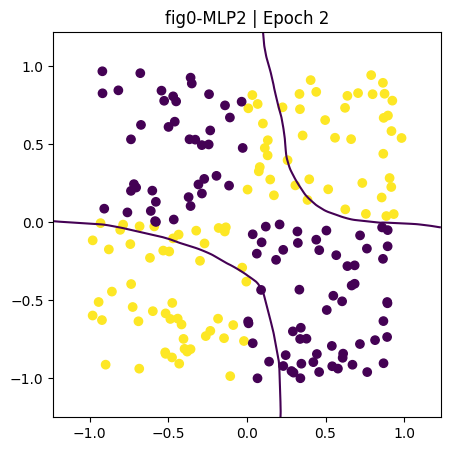

train_loss = 39.4012, val_loss = 30.5671, val_acc = 0.8400


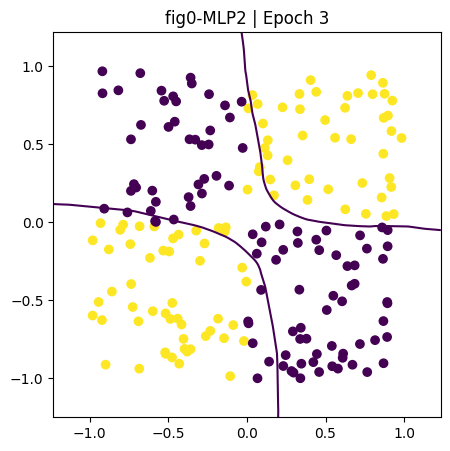

train_loss = 35.5838, val_loss = 27.2590, val_acc = 0.9150


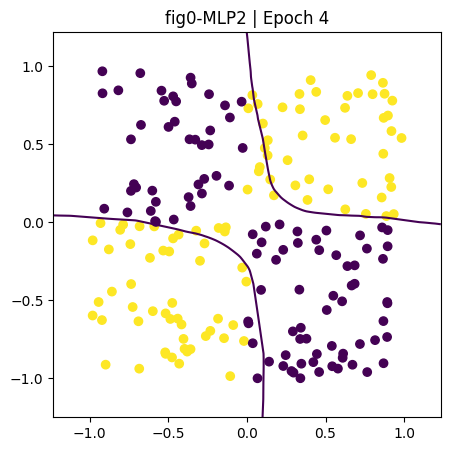

train_loss = 30.5827, val_loss = 23.1783, val_acc = 0.9300


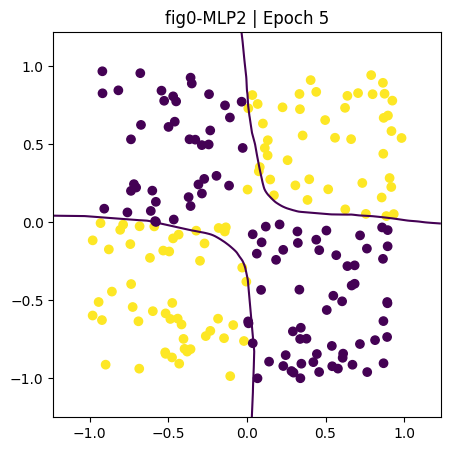

train_loss = 25.0304, val_loss = 18.9609, val_acc = 0.9500


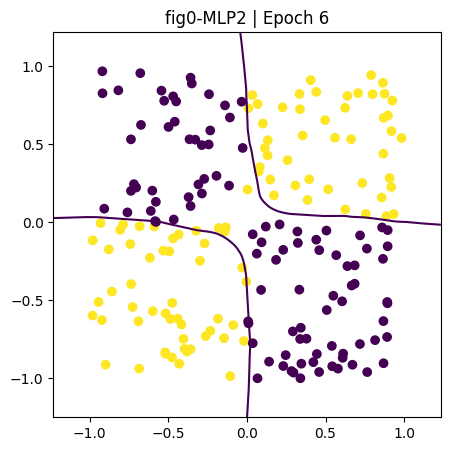

train_loss = 19.9727, val_loss = 15.4412, val_acc = 0.9650


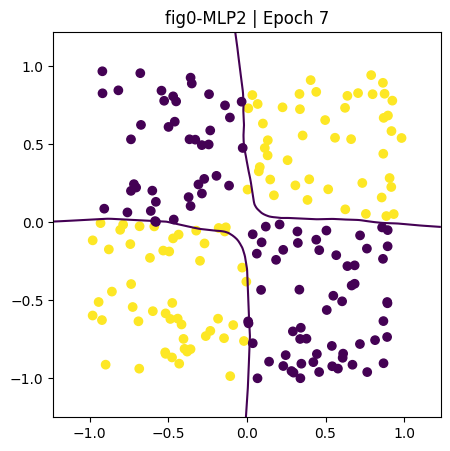

train_loss = 15.9953, val_loss = 12.8351, val_acc = 0.9600


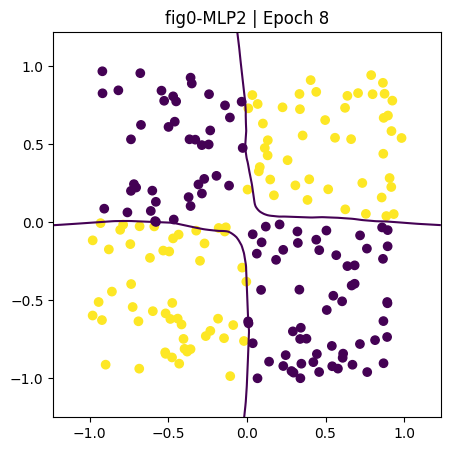

train_loss = 13.0884, val_loss = 10.9682, val_acc = 0.9800


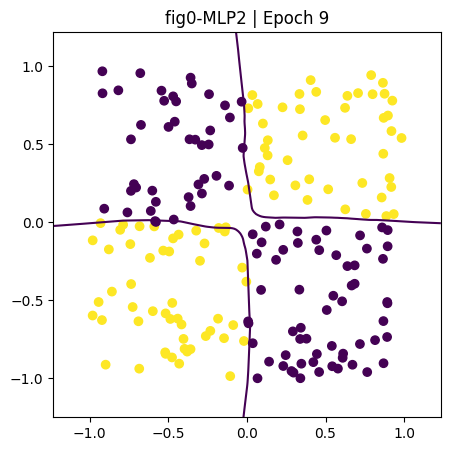

train_loss = 11.0470, val_loss = 9.5411, val_acc = 0.9700


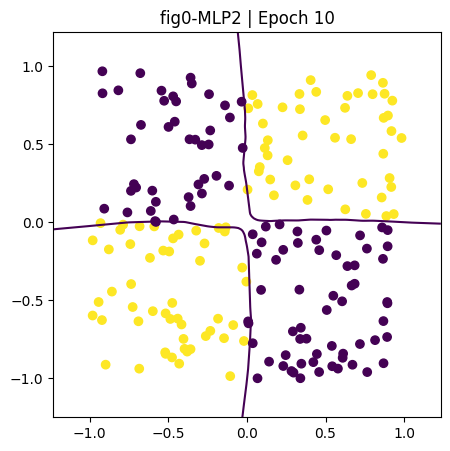

train_loss = 9.5991, val_loss = 8.6008, val_acc = 0.9750


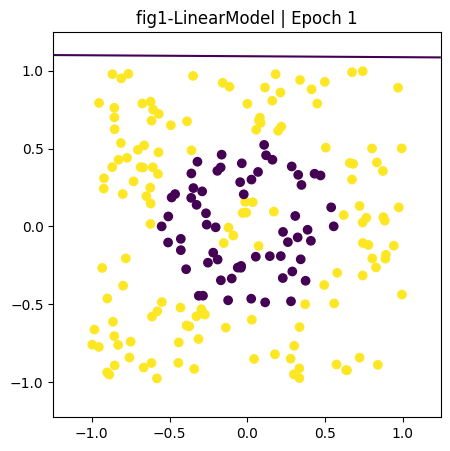

train_loss = 54.8175, val_loss = 41.7734, val_acc = 0.3100


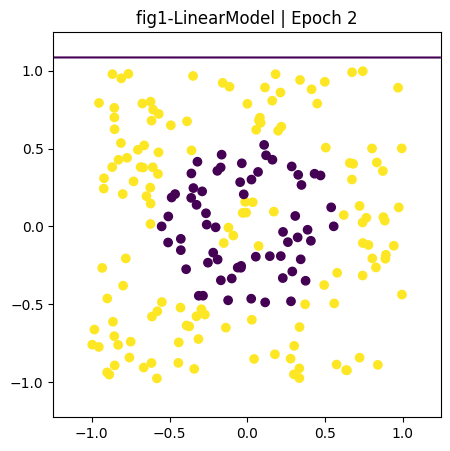

train_loss = 54.4019, val_loss = 41.4999, val_acc = 0.3100


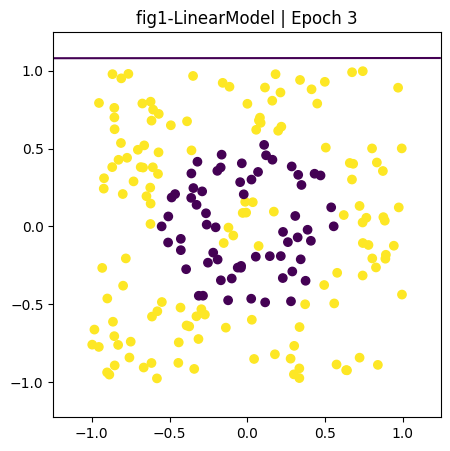

train_loss = 54.0002, val_loss = 41.2339, val_acc = 0.3100


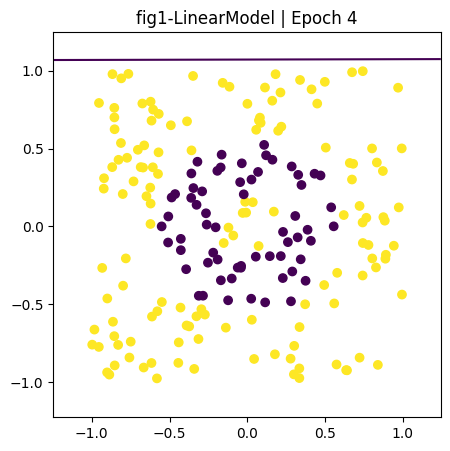

train_loss = 53.6019, val_loss = 40.9767, val_acc = 0.3100


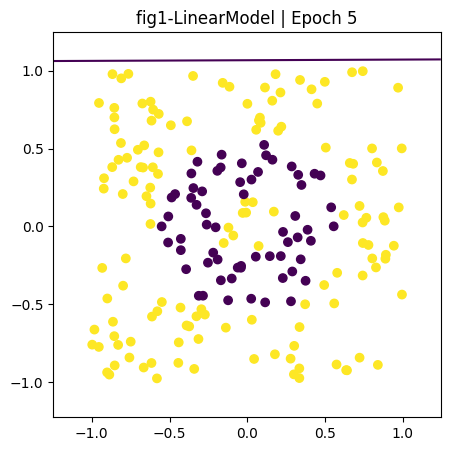

train_loss = 53.2150, val_loss = 40.7205, val_acc = 0.3100


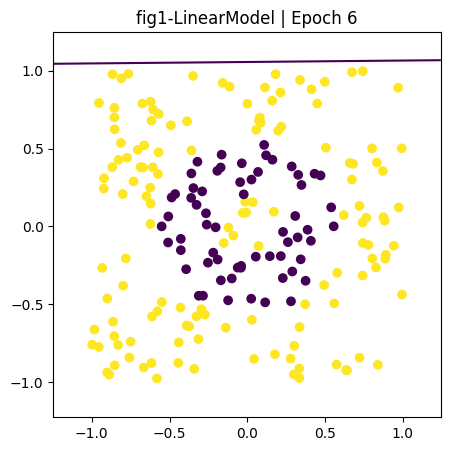

train_loss = 52.8210, val_loss = 40.4712, val_acc = 0.3100


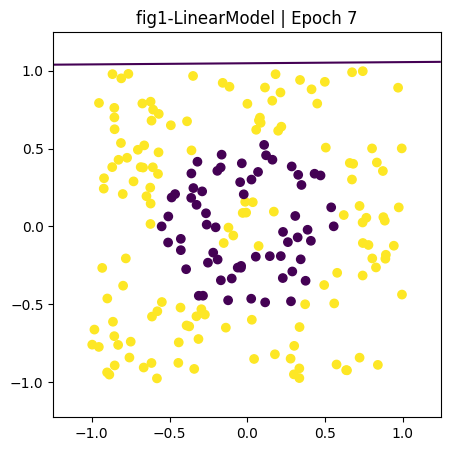

train_loss = 52.4492, val_loss = 40.2263, val_acc = 0.3100


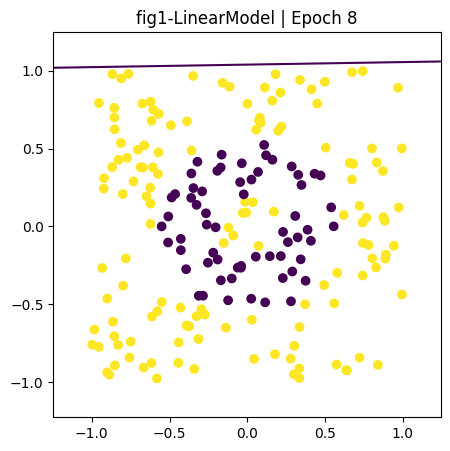

train_loss = 52.0752, val_loss = 39.9813, val_acc = 0.3100


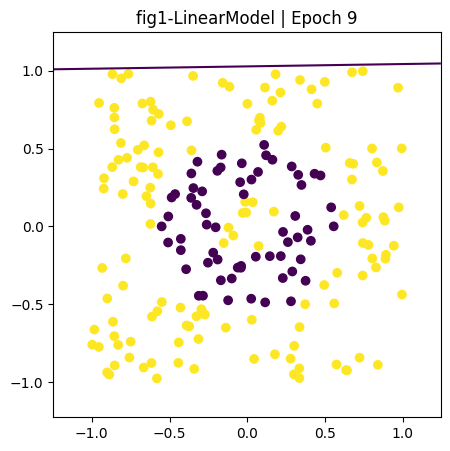

train_loss = 51.7104, val_loss = 39.7471, val_acc = 0.3100


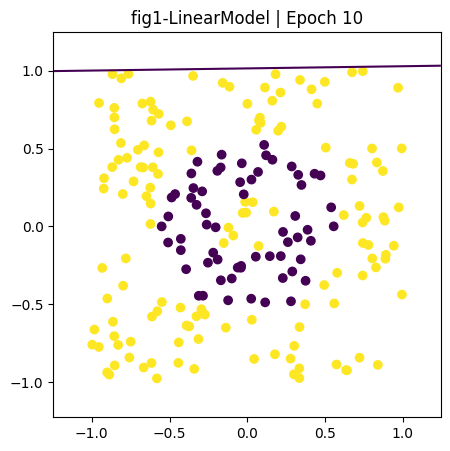

train_loss = 51.3491, val_loss = 39.5186, val_acc = 0.3100


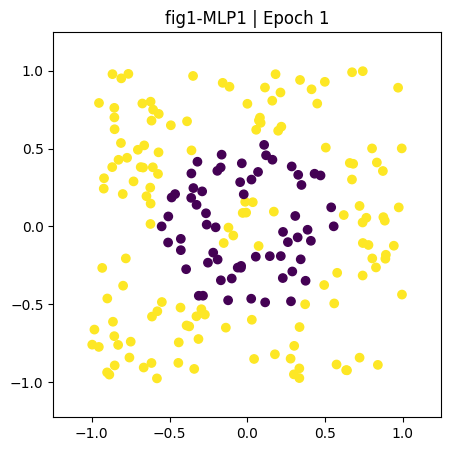

train_loss = 39.2617, val_loss = 30.8200, val_acc = 0.6900


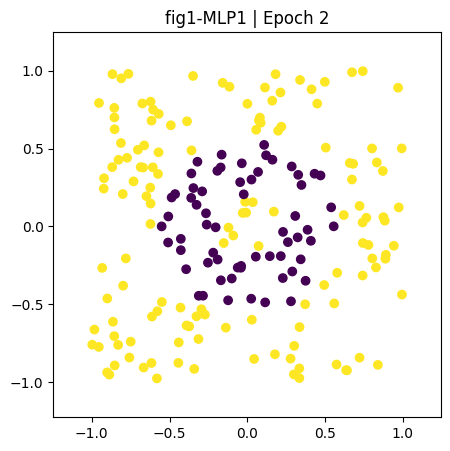

train_loss = 35.5066, val_loss = 29.8959, val_acc = 0.6900


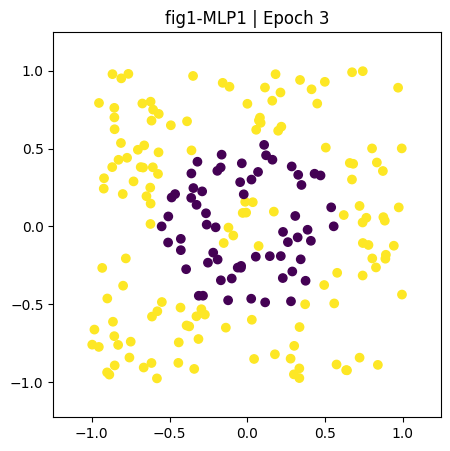

train_loss = 34.0499, val_loss = 29.7643, val_acc = 0.6900


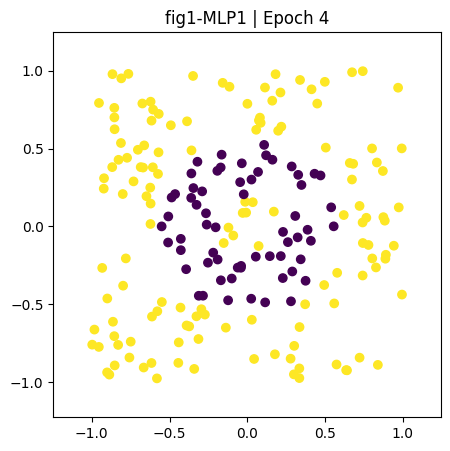

train_loss = 33.4032, val_loss = 29.5425, val_acc = 0.6900


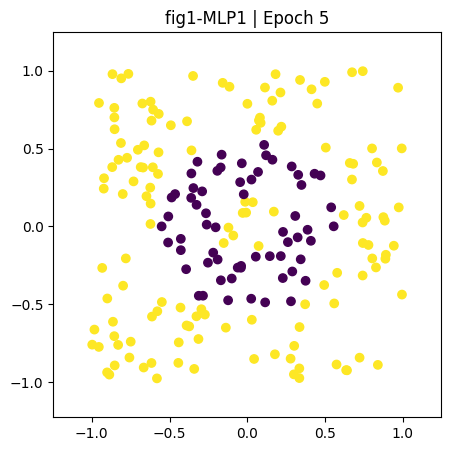

train_loss = 32.9309, val_loss = 29.1149, val_acc = 0.6900


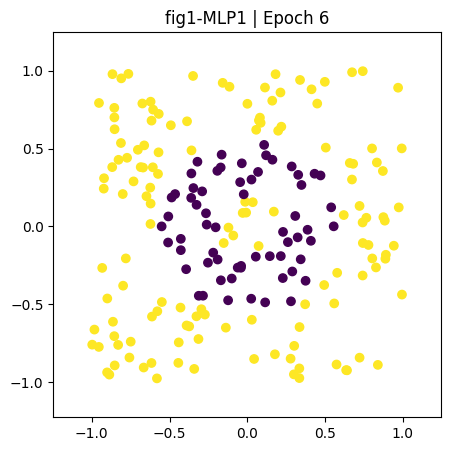

train_loss = 32.4089, val_loss = 28.6883, val_acc = 0.6900


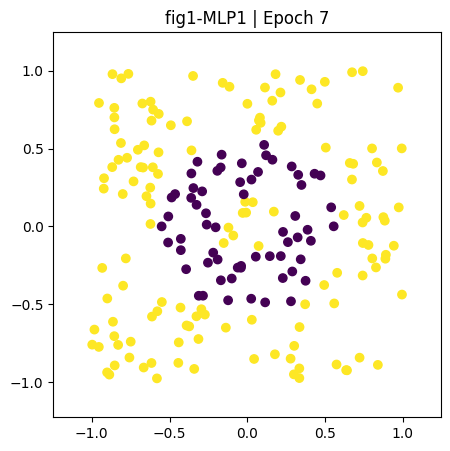

train_loss = 31.8624, val_loss = 28.2161, val_acc = 0.6900


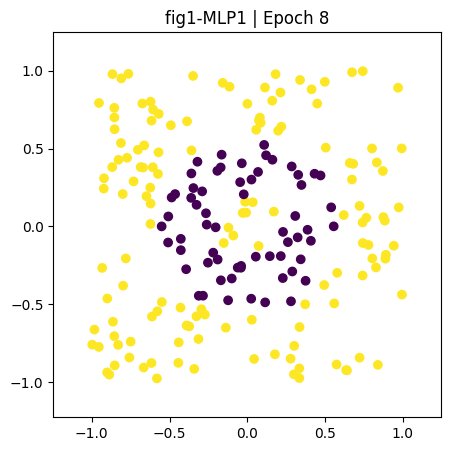

train_loss = 31.2567, val_loss = 27.6045, val_acc = 0.6900


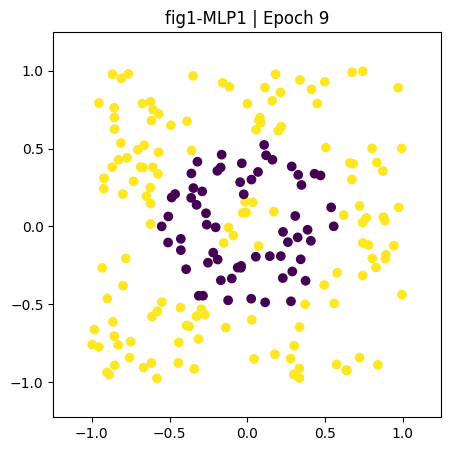

train_loss = 30.5990, val_loss = 26.9746, val_acc = 0.6900


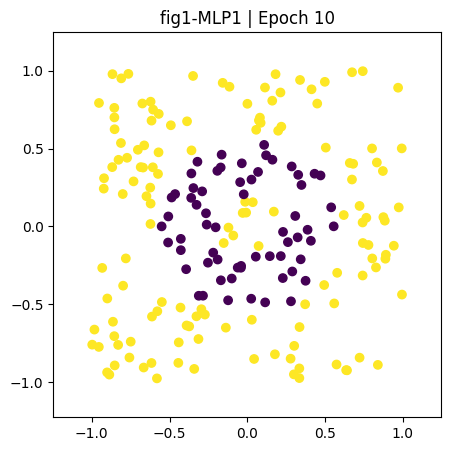

train_loss = 29.9157, val_loss = 26.2995, val_acc = 0.6900


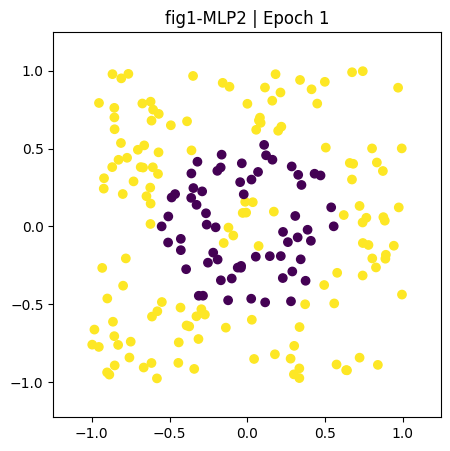

train_loss = 38.3388, val_loss = 29.4913, val_acc = 0.6900


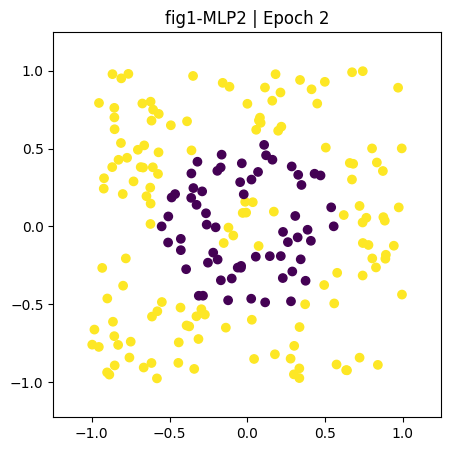

train_loss = 33.2130, val_loss = 29.4986, val_acc = 0.6900


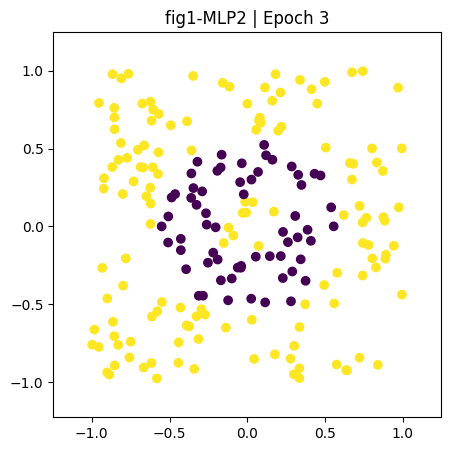

train_loss = 31.8637, val_loss = 27.7834, val_acc = 0.6900


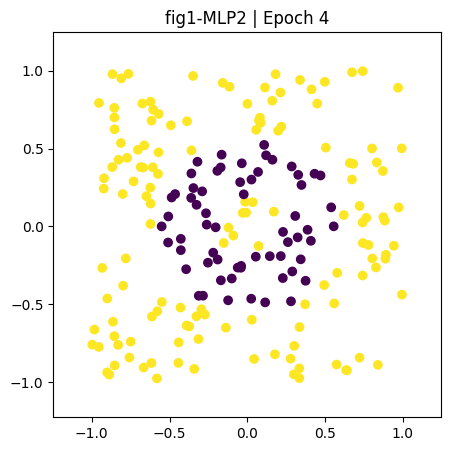

train_loss = 30.4007, val_loss = 26.4624, val_acc = 0.6900


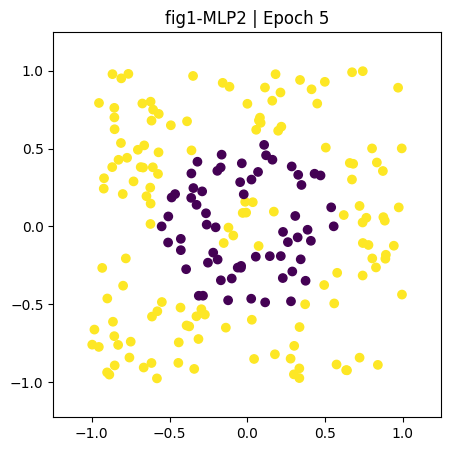

train_loss = 28.6925, val_loss = 24.6725, val_acc = 0.6900


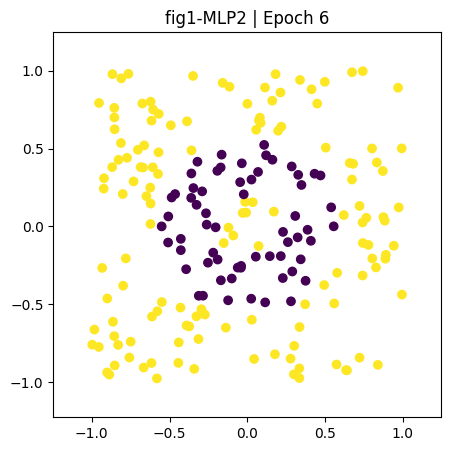

train_loss = 26.6820, val_loss = 22.7522, val_acc = 0.6900


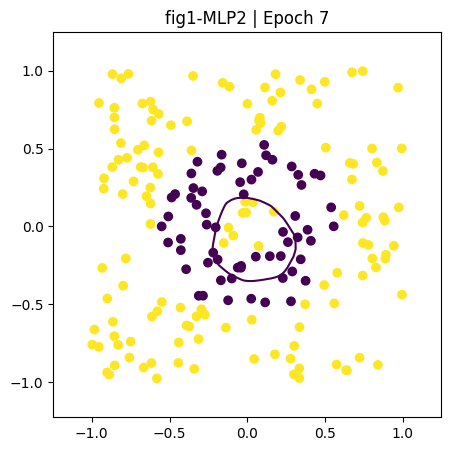

train_loss = 24.3569, val_loss = 20.4279, val_acc = 0.6900


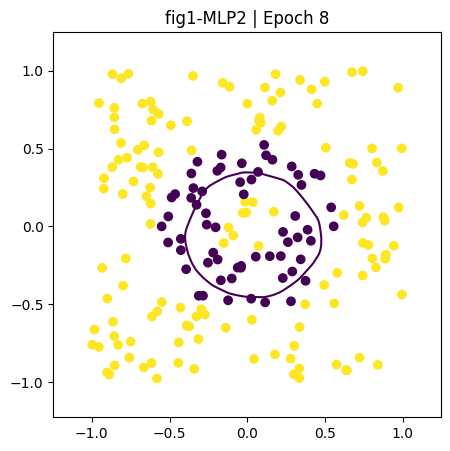

train_loss = 21.8760, val_loss = 18.3405, val_acc = 0.7750


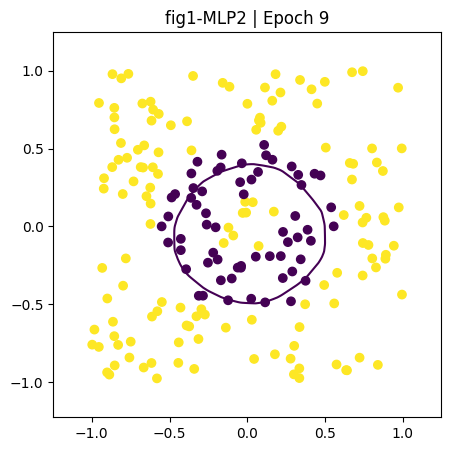

train_loss = 19.6355, val_loss = 16.5324, val_acc = 0.8150


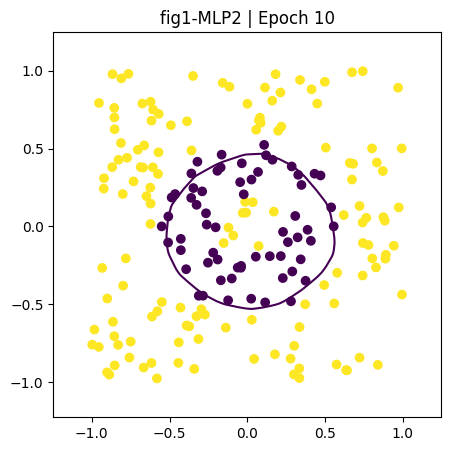

train_loss = 17.7002, val_loss = 15.0077, val_acc = 0.8800


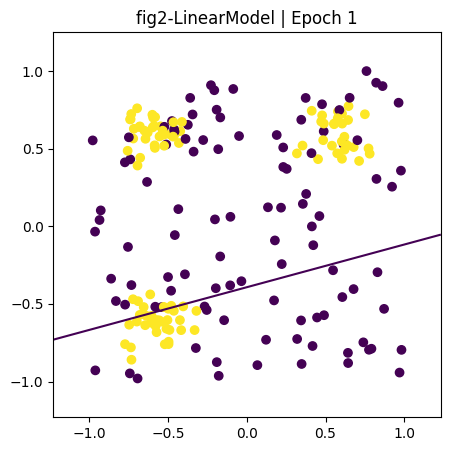

train_loss = 44.7001, val_loss = 34.6851, val_acc = 0.4950


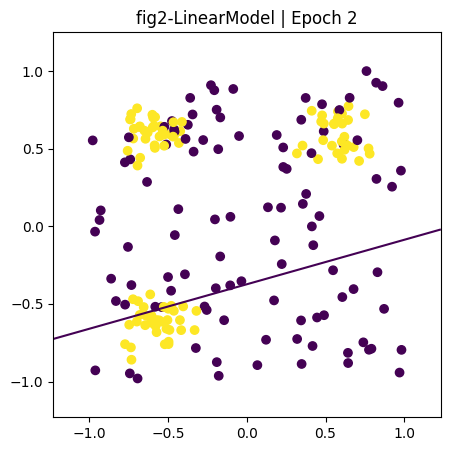

train_loss = 44.5380, val_loss = 34.5933, val_acc = 0.4850


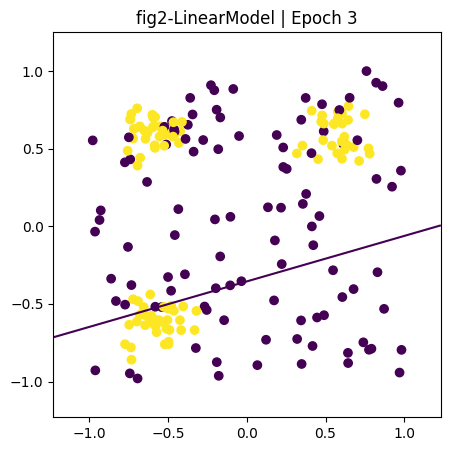

train_loss = 44.3805, val_loss = 34.5126, val_acc = 0.4850


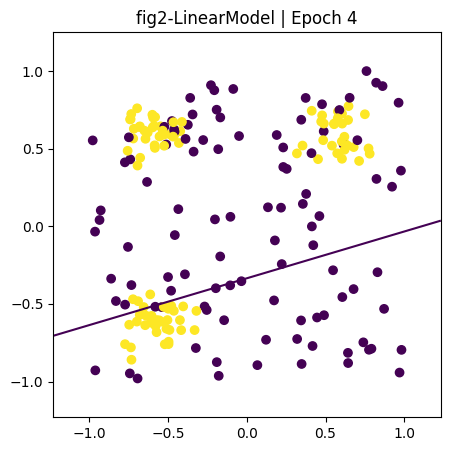

train_loss = 44.2304, val_loss = 34.4328, val_acc = 0.5050


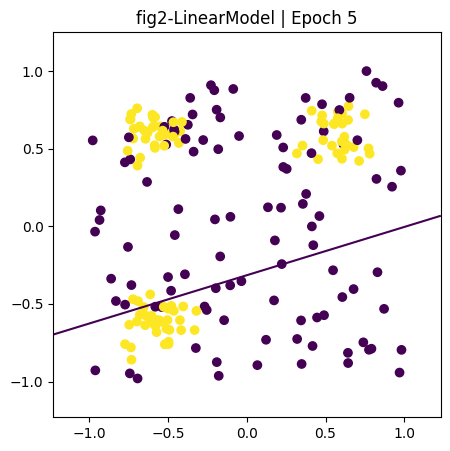

train_loss = 44.0846, val_loss = 34.3568, val_acc = 0.5000


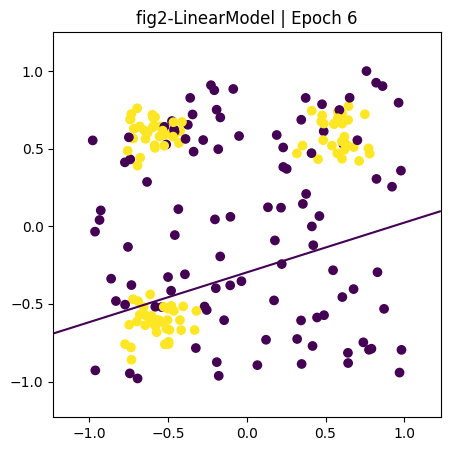

train_loss = 43.9475, val_loss = 34.2845, val_acc = 0.5050


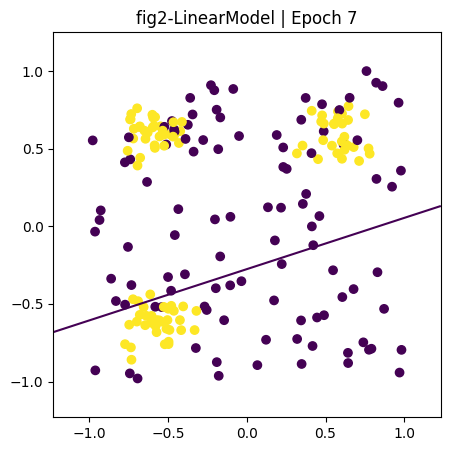

train_loss = 43.8157, val_loss = 34.2143, val_acc = 0.5050


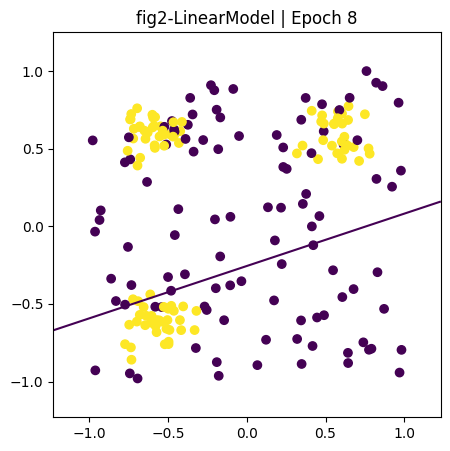

train_loss = 43.6881, val_loss = 34.1517, val_acc = 0.5100


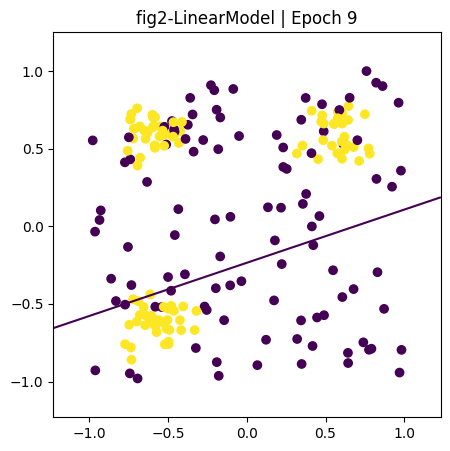

train_loss = 43.5658, val_loss = 34.0952, val_acc = 0.5150


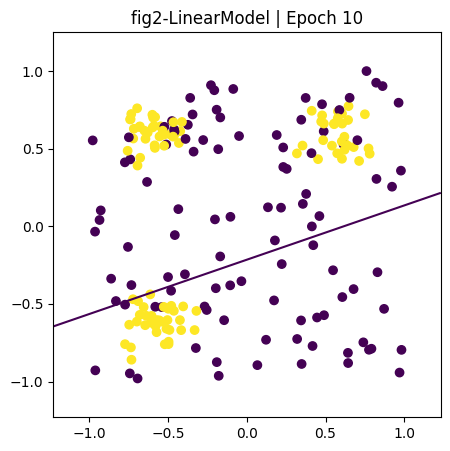

train_loss = 43.4462, val_loss = 34.0434, val_acc = 0.5050


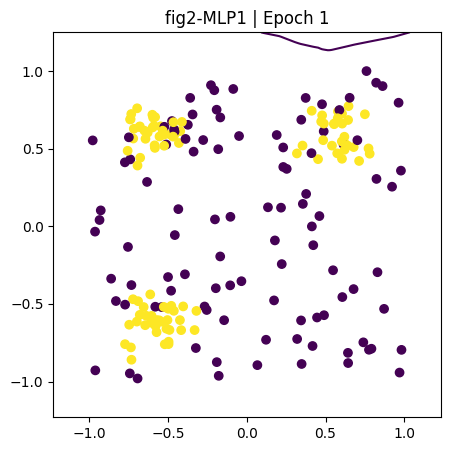

train_loss = 41.3849, val_loss = 33.6157, val_acc = 0.5150


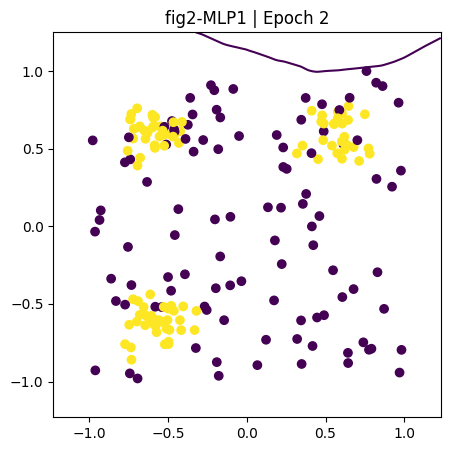

train_loss = 40.6981, val_loss = 33.5059, val_acc = 0.5150


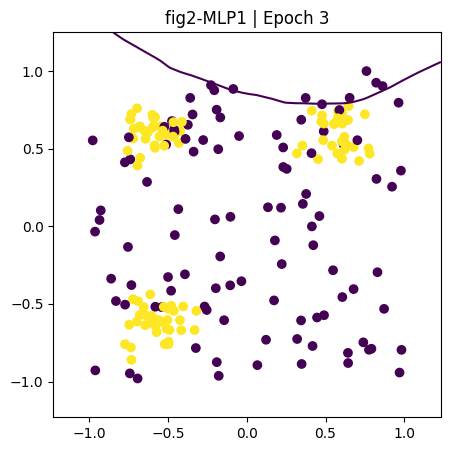

train_loss = 40.1893, val_loss = 33.1576, val_acc = 0.4850


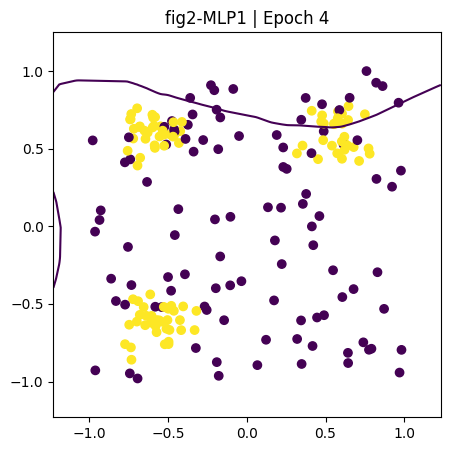

train_loss = 39.7336, val_loss = 32.7397, val_acc = 0.5150


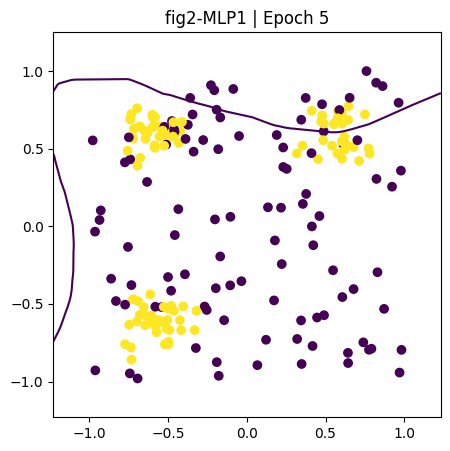

train_loss = 39.2803, val_loss = 32.4954, val_acc = 0.5100


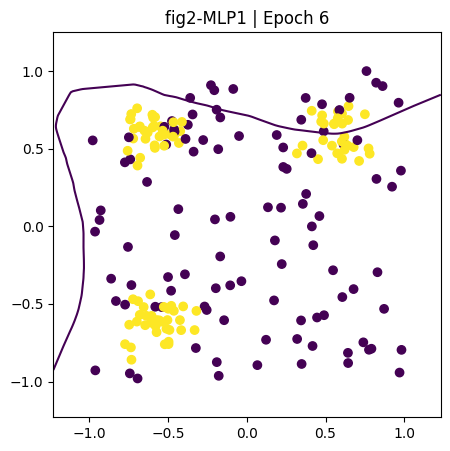

train_loss = 38.8705, val_loss = 32.2619, val_acc = 0.5100


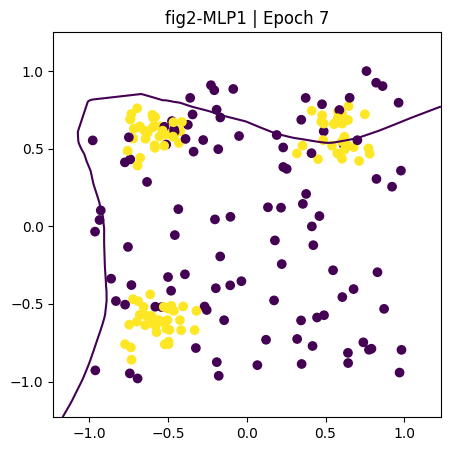

train_loss = 38.4623, val_loss = 31.8888, val_acc = 0.5000


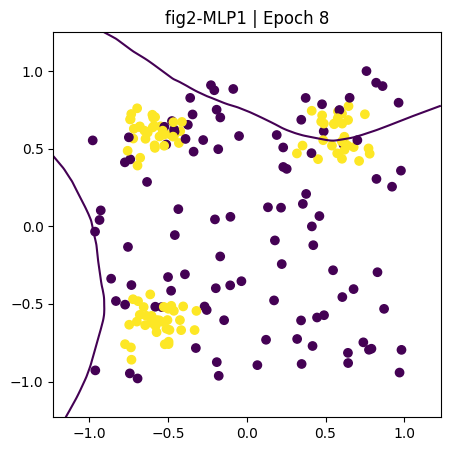

train_loss = 38.0421, val_loss = 31.8173, val_acc = 0.5200


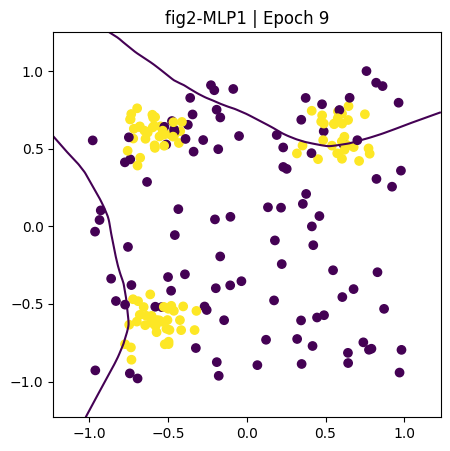

train_loss = 37.6639, val_loss = 31.4175, val_acc = 0.5000


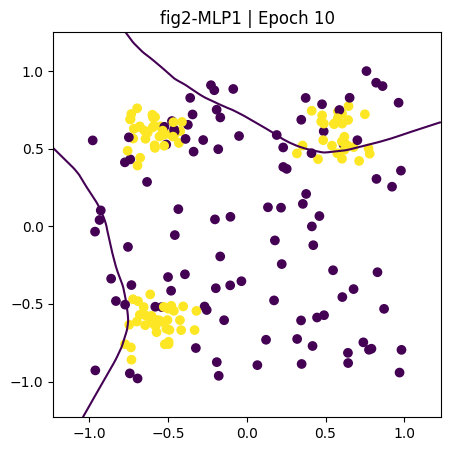

train_loss = 37.2920, val_loss = 31.2913, val_acc = 0.5150


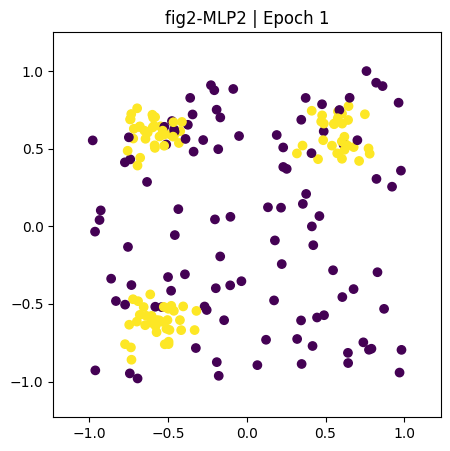

train_loss = 42.3984, val_loss = 34.2245, val_acc = 0.5150


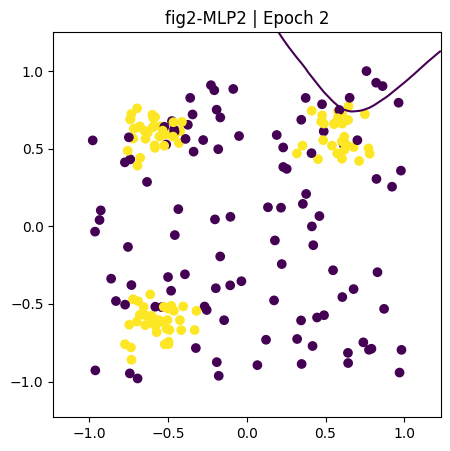

train_loss = 41.0391, val_loss = 33.1724, val_acc = 0.5000


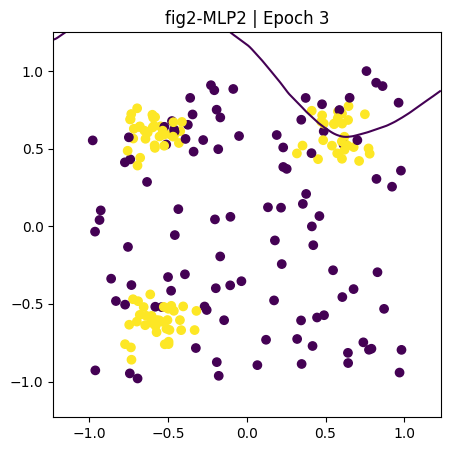

train_loss = 39.7461, val_loss = 32.3163, val_acc = 0.5450


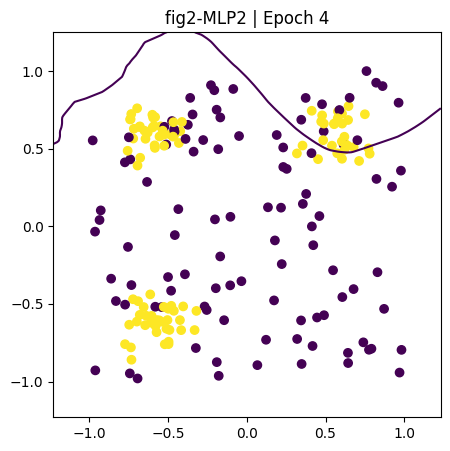

train_loss = 38.1772, val_loss = 31.1158, val_acc = 0.5600


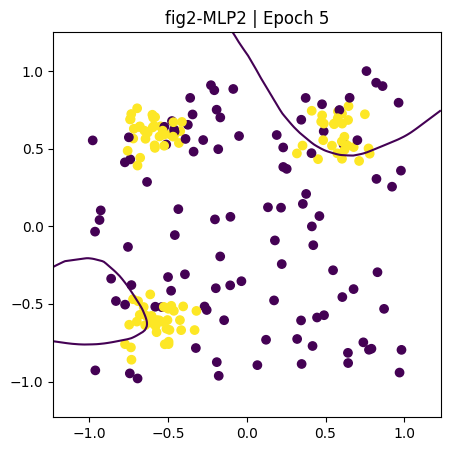

train_loss = 36.6118, val_loss = 30.1647, val_acc = 0.5800


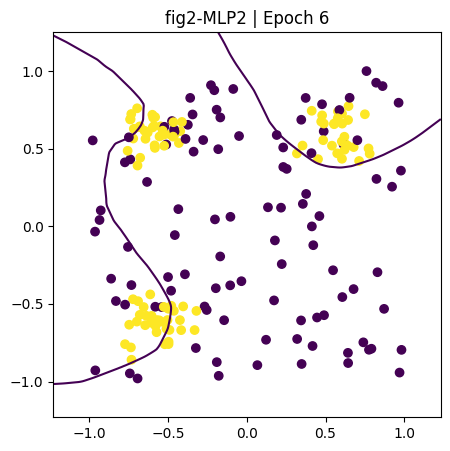

train_loss = 35.1116, val_loss = 28.9357, val_acc = 0.6800


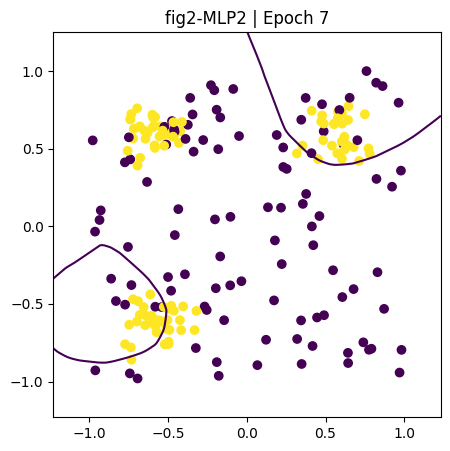

train_loss = 33.7235, val_loss = 28.4840, val_acc = 0.6600


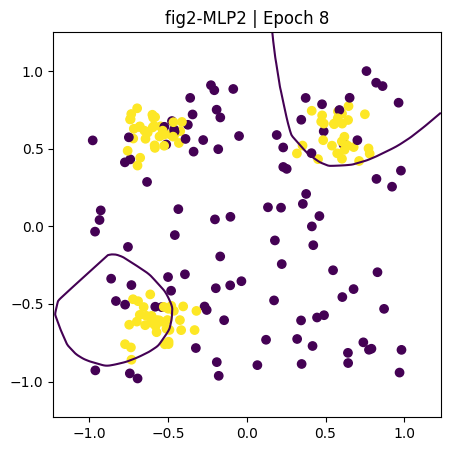

train_loss = 32.5764, val_loss = 27.9389, val_acc = 0.6850


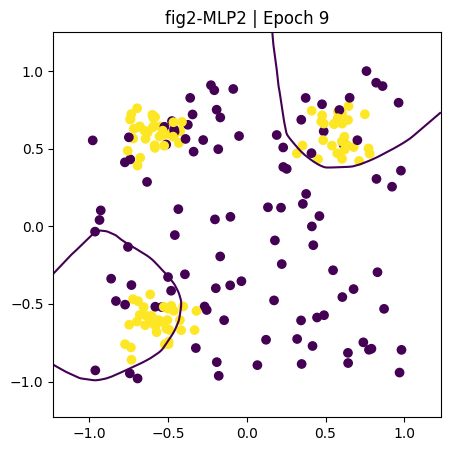

train_loss = 31.4989, val_loss = 26.8828, val_acc = 0.6800


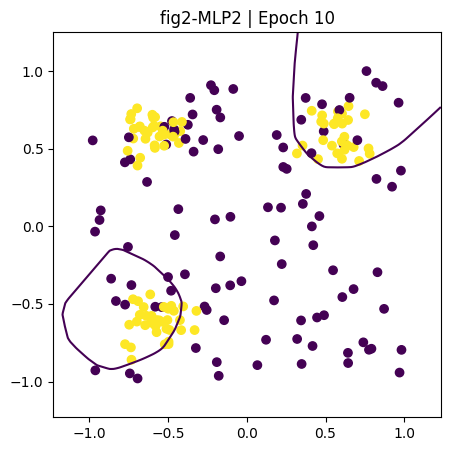

train_loss = 30.5945, val_loss = 26.5065, val_acc = 0.6950


In [26]:
for i, ((X_train, y_train),(X_val, y_val)) in enumerate(zip(train_sets, val_sets)):
    for ModelClass in [LinearModel,MLP1,MLP2]:
        model = ModelClass()
        train(f"fig{i}-{ModelClass.__name__}", model, X_train, y_train, X_val, y_val, epochs=10)


# Часть 2

In [27]:
df_red = pd.read_csv('/content/winequality-red.csv', sep=';')
df_white = pd.read_csv('/content/winequality-white.csv', sep=';')

In [28]:
df = pd.concat((df_red, df_white), ignore_index=True)

In [29]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [31]:
X = df.drop(['quality'], axis=1)
y = df['quality']-3

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=SEED)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.long).to(device)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.long).to(device)

In [35]:
class MLP(nn.Module):
    def __init__(self, input_layer, hidden_layers, output_layer, activation='relu'):
        super().__init__()
        layers = []
        prev = input_layer
        act = {'relu': nn.ReLU(),
            'tanh': nn.Tanh()}[activation]
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(act)
            prev = h
        layers.append(nn.Linear(prev, output_layer))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [36]:
def train_and_evaluate(config, X_train_t, y_train_t, X_val_t, y_val_t):
    input_dim = X_train_t.shape[1]
    output_dim = y.unique().shape[0]
    model = MLP(input_dim, hidden_layers=config['hidden_layers'], output_layer=output_dim, activation=config['activation']).to(device)
    criterion = nn.CrossEntropyLoss()
    if config['optimizer'] == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'])

    batch_size = config['batch_size']
    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds = TensorDataset(X_val_t, y_val_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_w = None

    for epoch in range(config['epochs']):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for data, target in train_loader:
            optimizer.zero_grad(set_to_none=True)
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * data.size(0)
            preds = output.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += data.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = criterion(output, target)
                running_loss += loss.item() * data.size(0)
                preds = output.argmax(dim=1)
                correct += (preds == target).sum().item()
                total += data.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_w = model.state_dict()

        print(f"Epoch {epoch+1}/{config['epochs']}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    model.load_state_dict(best_model_w)
    return model, history

In [37]:
param_grid = {
    'hidden_layers': [(256,128,64), (256,128,64,32), (512,256,128,64)],
    'activation': ['relu', 'tanh'],
    'lr': [1e-3, 5e-4],
    'batch_size': [32, 64, 256],
    'optimizer': ['adamw','sgd'],
    'epochs': [20,40]
}

all_keys = list(param_grid.keys())
configs = []
for combo in itertools.product(*(param_grid[k] for k in all_keys)):
    cfg = dict(zip(all_keys, combo))
    configs.append(cfg)

print("Total configs:", len(configs))
best_val_loss = float('inf')
best_entry = None
results = []
best_model = None

for i, cfg in enumerate(configs):
    print("\n=== Run", i+1, "of", len(configs), "cfg:", cfg)
    model, hist = train_and_evaluate(cfg, X_train_t, y_train_t, X_test_t, y_test_t)
    val_loss = hist['val_loss'][-1]
    val_acc = hist['val_acc'][-1]
    results.append({'config': cfg, 'history': hist, 'val_loss': val_loss, 'val_acc': val_acc, 'model_state_dict': copy.deepcopy(model.state_dict())})
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_acc = val_acc
        best_entry = results[-1]
        best_model = model

print("\nBest val_loss:", best_val_loss)
print("Best val_acc: ", best_acc)
print("Best config:", best_entry['config'])


Total configs: 144

=== Run 1 of 144 cfg: {'hidden_layers': (256, 128, 64), 'activation': 'relu', 'lr': 0.001, 'batch_size': 32, 'optimizer': 'adamw', 'epochs': 20}
Epoch 1/20: train_loss=1.2152, val_loss=1.1040, train_acc=0.5043, val_acc=0.5374
Epoch 2/20: train_loss=1.0863, val_loss=1.0642, train_acc=0.5531, val_acc=0.5431
Epoch 3/20: train_loss=1.0504, val_loss=1.0926, train_acc=0.5615, val_acc=0.5215
Epoch 4/20: train_loss=1.0322, val_loss=1.0321, train_acc=0.5663, val_acc=0.5569
Epoch 5/20: train_loss=1.0118, val_loss=1.0318, train_acc=0.5731, val_acc=0.5569
Epoch 6/20: train_loss=1.0044, val_loss=1.0388, train_acc=0.5676, val_acc=0.5477
Epoch 7/20: train_loss=0.9904, val_loss=1.0355, train_acc=0.5692, val_acc=0.5497
Epoch 8/20: train_loss=0.9864, val_loss=1.0239, train_acc=0.5764, val_acc=0.5544
Epoch 9/20: train_loss=0.9756, val_loss=1.0373, train_acc=0.5850, val_acc=0.5385
Epoch 10/20: train_loss=0.9634, val_loss=1.0217, train_acc=0.5876, val_acc=0.5544
Epoch 11/20: train_loss=

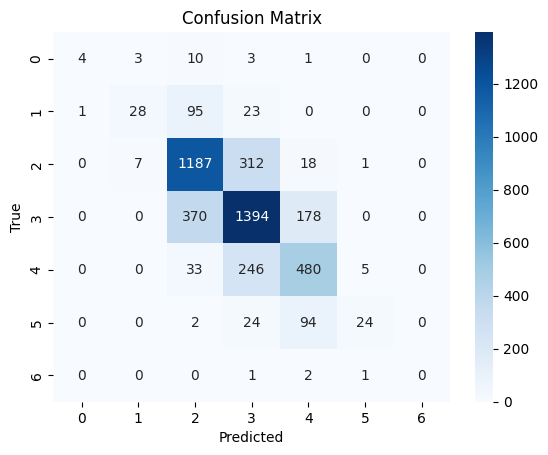

In [49]:
with torch.no_grad():
    output = best_model(X_train_t)
    preds = output.argmax(dim=1)
    cm = confusion_matrix(y_train_t, preds, labels=np.arange(y_train_t.unique().shape[0]))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.arange(y_train_t.unique().shape[0]),
            yticklabels=np.arange(y_train_t.unique().shape[0]))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

Лучше всего определяются классы 2 и 3 (quality 5 и 6 соответственно). Отальные классы определяются значительно хуже, возможно из-за крайне малого количество элементов выборки с этими классами